## Processing data with IMProToo

IMProToo is a Python package for processing MRR data developed by Maximillian Maahn. It dealiases the full doppler spectra. Given that the Nyquist velocity of the Micro Rain Radar is around 12 m/s, this helps recover the doppler spectra during strong downdrafts, heavy rain, and hail conditions.


## References
Maahn, M. and Kollias, P.: Improved Micro Rain Radar snow measurements using Doppler spectra post-processing, Atmos. Meas. Tech. Discuss., 5, 4771-4808, doi:10.5194/amtd-5-4771-2012, 2012. http://www.atmos-meas-tech-discuss.net/5/4771/2012/amtd-5-4771-2012.html

In [3]:
improtoo_ds = IMProToo.mrrRawData("data/0520.raw")

1 of 1: data/0520.raw


In [7]:
processed_spec = IMProToo.MrrZe(improtoo_ds)

In [10]:
processed_spec.averageSpectra(60)
processed_spec.co["ncCreator"] = "Robert Jackson, Argonne National Laboratory"
processed_spec.co["ncDescription"] = "MRR data from CROCUS Urban Canyons"
processed_spec.co["dealiaseSpectrum"] = True
processed_spec.rawToSnow()
processed_spec.writeNetCDF("0520.improtoo.nc")

/Users/rjackson/miniforge3/envs/crocus_env/lib/python3.13/site-packages/IMProToo/core.py:1286: UserWarning: Dealiasing failed! peak boundaries fall out of spectrum. time step 613, peak number 15, most likely at height 18
  warnings.warn('Dealiasing failed! peak boundaries fall out of spectrum. time step '+str(


In [30]:
improtoo_spec = xr.open_dataset("0520.improtoo.nc")
improtoo_spec = improtoo_spec.set_coords(["time", "height"])

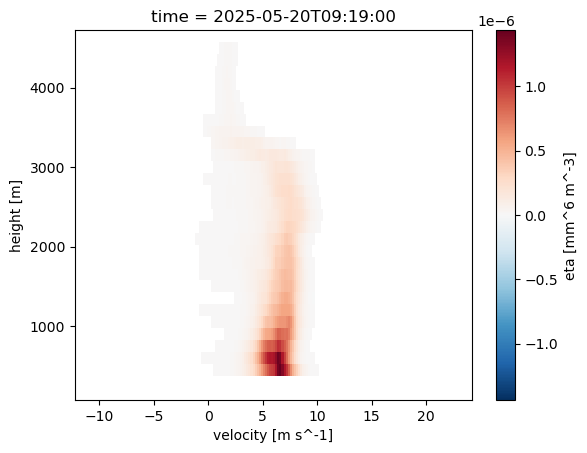

In [32]:
improtoo_spec["eta"].where(improtoo_spec["etaMask"] == 0).sel(
    time="2025-05-20T09:19:00", method='nearest').plot(y='height')

In [40]:
out = raprom.process_file('data/0520.raw')

File in process  /Users/rjackson/RaProM/data/0520
2026-05-28 14:31:16.980753
2026-05-28 14:32:10.554508




In [41]:
ds = xr.open_dataset(out)
ds

<xarray.Dataset> Size: 15MB
Dimensions:                              (time: 1440, Height: 31,
                                          PIA_Height: 32, DropSize: 64,
                                          BB_Height: 1, Dm_ax: 33, Nw_ax: 94)
Coordinates:
  * time                                 (time) datetime64[ns] 12kB 2025-05-2...
  * Height                               (Height) float32 124B 150.0 ... 4.65...
  * PIA_Height                           (PIA_Height) float32 128B 0.0 ... 4....
  * DropSize                             (DropSize) float32 256B nan ... nan
  * BB_Height                            (BB_Height) float32 4B 9.969e+36
  * Dm_ax                                (Dm_ax) float32 132B 0.2 0.3 ... 3.4
  * Nw_ax                                (Nw_ax) float32 376B -2.0 -1.9 ... 7.3
Data variables: (12/22)
    W                                    (time, Height) float32 179kB ...
    spectral width                       (time, Height) float32 179kB ...
    Skewness                             (time, Height) float32 179kB ...
    Kurtosis                             (time, Height) float32 179kB ...
    PIA                                  (time, PIA_Height) float32 184kB ...
    PIA_all                              (time, PIA_Height) float32 184kB ...
    ...                                   ...
    Noise                                (time, Height) float32 179kB ...
    Nw                                   (time, Height) float32 179kB ...
    Dm                                   (time, Height) float32 179kB ...
    BB_bottom                            (time, BB_Height) float32 6kB ...
    BB_top                               (time, BB_Height) float32 6kB ...
    TyPrecipi                            (Dm_ax, Nw_ax) float32 12kB ...
Attributes:
    description:  Data processed by MRR radar
    author:       Albert Garcia Benadí
    orcid:        0000-0002-5560-4392

In [35]:
ds_metek = xr.open_dataset('data/0520.pro', engine='metek')

In [36]:
ds_metek

<xarray.Dataset> Size: 430MB
Dimensions:                      (sample: 64, time: 8660, range: 31,
                                  index: 268455)
Coordinates:
  * time                         (time) datetime64[ns] 69kB 2025-05-20T00:00:...
  * range                        (range) float64 248B 150.0 300.0 ... 4.65e+03
    velocity_bins                (sample) float64 512B ...
Dimensions without coordinates: sample, index
Data variables: (12/17)
    transfer_function            (time, range) float64 2MB ...
    spectral_reflectivity        (index, sample) float64 137MB ...
    drop_size                    (index, sample) float64 137MB ...
    drop_number_density          (index, sample) float64 137MB ...
    percentage_valid_spectra     (time) float64 69kB ...
    path_integrated_attenuation  (time, range) float64 2MB ...
    ...                           ...
    altitude                     float64 8B ...
    longitude                    float64 8B ...
    latitude                     float64 8B ...
    spectrum_index               (time, range) float64 2MB ...
    azimuth                      (time) float64 69kB ...
    elevation                    (time) float64 69kB ...

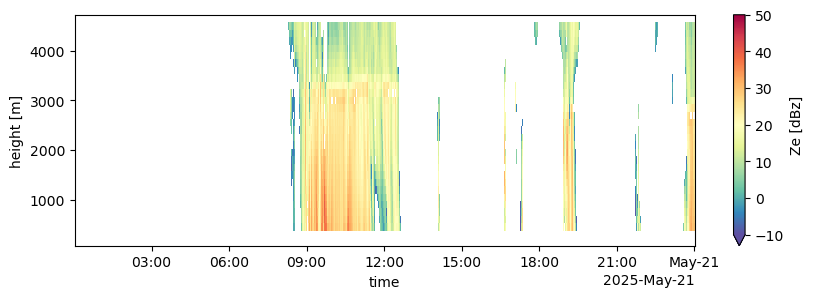

In [37]:
fig, ax = plt.subplots(figsize=(10, 3))
improtoo_spec['Ze'].T.plot(cmap='Spectral_r', vmin=-10, vmax=50, y='height')

NameError: name 'ds' is not defined

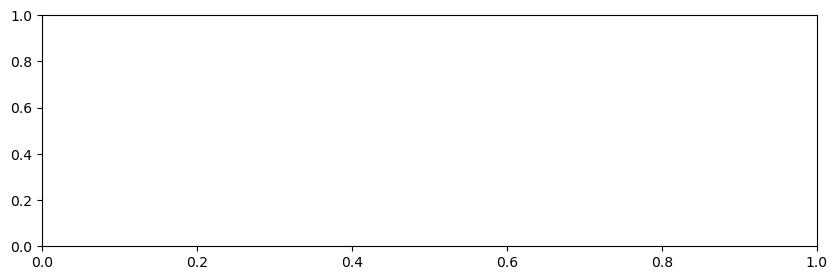

In [38]:
fig, ax = plt.subplots(figsize=(10, 3))
ds['Ze'].T.plot(cmap='Spectral_r', vmin=-10, vmax=50)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ds_metek['reflectivity'].T.plot(cmap='Spectral_r', vmin=-10, vmax=50)

In [42]:
parsivel = xr.open_dataset('data/crocus.adm.parsivel.20250520.000000.b1.nc')
parsivel

<xarray.Dataset> Size: 1MB
Dimensions:                      (time: 1440, bins: 32, bin_edges: 33)
Coordinates:
  * time                         (time) datetime64[ns] 12kB 2025-05-19T23:56:...
  * bins                         (bins) float64 256B 0.06225 0.1895 ... 25.24
  * bin_edges                    (bin_edges) float64 264B 0.0 0.1245 ... 26.78
Data variables: (12/29)
    velocity                     (time, bins) float64 369kB ...
    Nd                           (time, bins) float64 369kB ...
    num_particles                (time) int64 12kB ...
    spectrum_fall_velocity       (time, bins) float64 369kB ...
    rain_rate                    (time) float64 12kB ...
    Zh                           (time) float64 12kB ...
    ...                           ...
    power_supply_voltage         (time) float64 12kB ...
    sensor_head_heating_current  (time) float64 12kB ...
    sensor_heating_temperature   (time) int64 12kB ...
    temperature_right_head       (time) int64 12kB ...
    temperature_left_head        (time) int64 12kB ...
    sensor_time                  (time) datetime64[ns] 12kB ...
Attributes:
    site:                Argonne Deployable Mast
    mentors:             Liz Wawrzyniak, Joseph O'Brien, Bobby Jackson, Bhupe...
    mentor_emails:       ewawrzyniak@anl.gov, obrienj@anl.gov, rjackson@anl.g...
    mentor_institution:  Argonne National Laboratory
    mentor_orcids:       0000-0003-4655-6912, 0000-0003-2518-1234
    contributors:        Scott Collis, Paytsar Muradyan, Max Grover, Matt Tuf...

In [43]:
imptoo_rr = rainrate_from_improtoo.rainrate_from_improtoo(improtoo_spec)

In [45]:
imptoo_rr

<xarray.DataArray (time: 1440, range: 31)> Size: 357kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan, 1.40218734, ..., 0.54138572, 0.46327673,
               nan],
       [       nan,        nan, 1.35087221, ..., 0.56268769, 0.54991392,
               nan],
       [       nan,        nan, 1.27209438, ..., 0.51995372, 0.62270572,
               nan]], shape=(1440, 31))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2025-05-20T00:02:00 ... 2025-05-21T00...
  * range    (range) float64 248B 1.0 2.0 3.0 4.0 5.0 ... 28.0 29.0 30.0 31.0
    height   (time, range) float64 357kB 150.0 300.0 450.0 ... 4.5e+03 4.65e+03
Attributes:
    units:        mm h-1
    long_name:    Rainfall rate from inverted Doppler spectrum
    description:  Zenith-pointing MRR retrieval: Atlas (1973) v(D) inverted w...

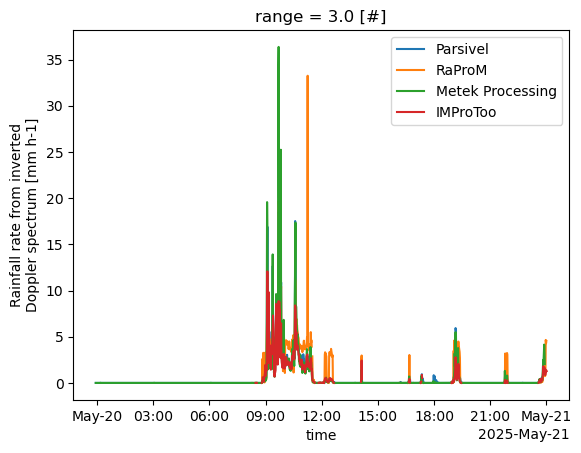

In [58]:
parsivel['rain_rate'].plot(label='Parsivel')
ds['RR'].isel(Height=0).plot(label='RaProM')
ds_metek['rainfall_rate'].isel(range=0).plot(label='Metek Processing')
imptoo_rr.isel(range=2).plot(label="IMProToo")
plt.legend()

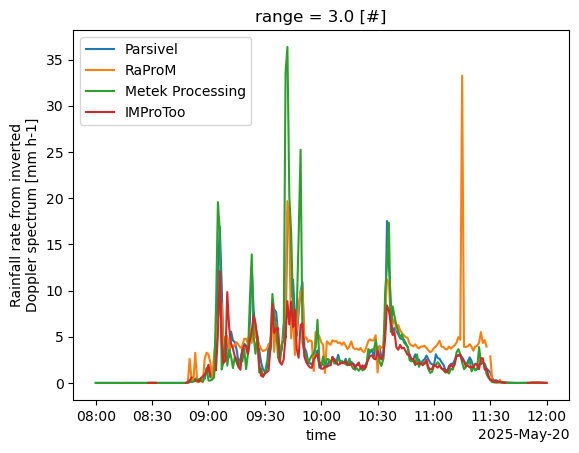

In [57]:
time_range = ('2025-05-20T08:00:00', '2025-05-20T12:00:00')
parsivel['rain_rate'].sel(time=slice(time_range[0], time_range[1])).plot(label='Parsivel')
ds['RR'].isel(Height=0).sel(time=slice(time_range[0], time_range[1])).plot(label='RaProM')
ds_metek['rainfall_rate'].sel(time=slice(time_range[0], time_range[1])).isel(range=0).plot(label='Metek Processing')
imptoo_rr.isel(range=2).sel(time=slice(time_range[0], time_range[1])).plot(label="IMProToo")
plt.legend()

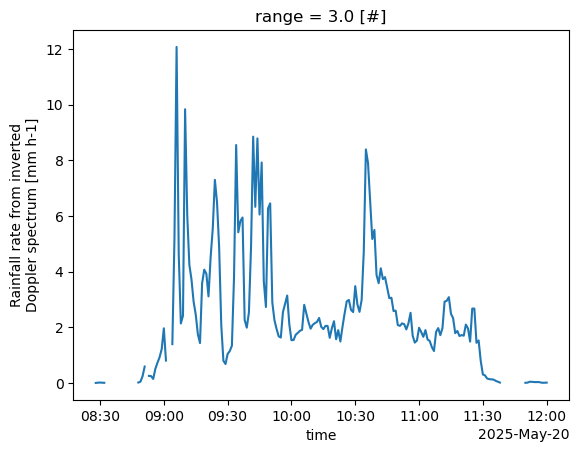

In [56]:
imptoo_rr.isel(range=2).sel(time=slice(time_range[0], time_range[1])).plot(label="IMProToo")

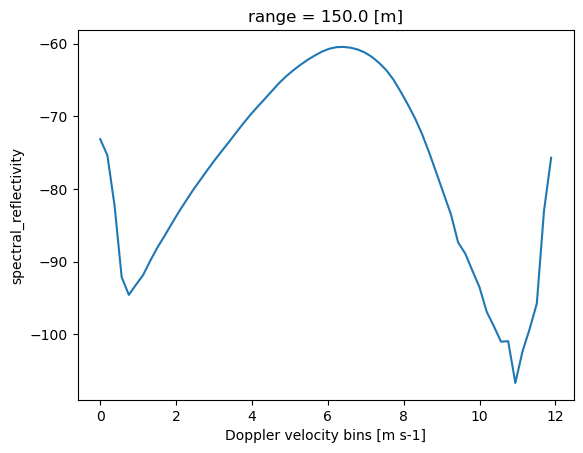

In [11]:
samples = ds_metek['spectrum_index'].sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).isel(range=0)
ds_metek['spectral_reflectivity'][samples, :].mean(dim='time').plot(x='velocity_bins')

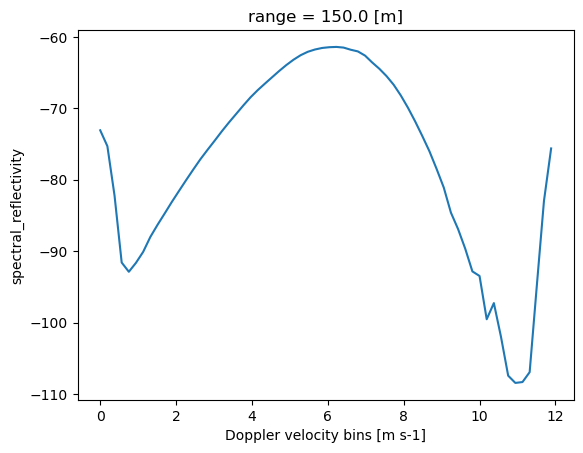

In [12]:
samples = ds_metek['spectrum_index'].sel(time=slice('2025-05-20T09:00:00', '2025-05-20T09:30:00')).isel(range=0)
ds_metek['spectral_reflectivity'][samples, :].mean(dim='time').plot(x='velocity_bins')

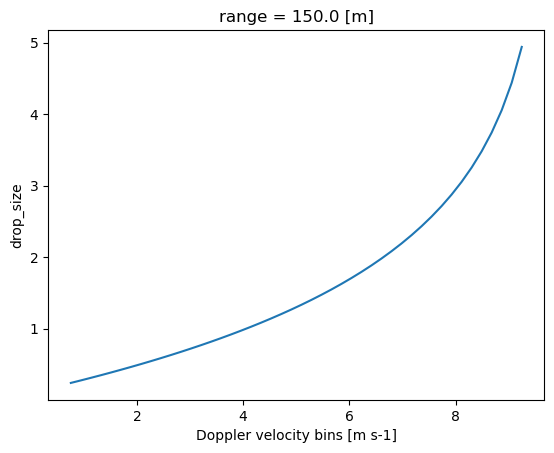

In [13]:
samples = ds_metek['spectrum_index'].sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).isel(range=0)
ds_metek['drop_size'][samples, :].mean(dim='time').plot(x='velocity_bins')

Text(0, 0.5, 'Micro Rain Radar Rain Rate [$mm\\ hr^{-1}$]')

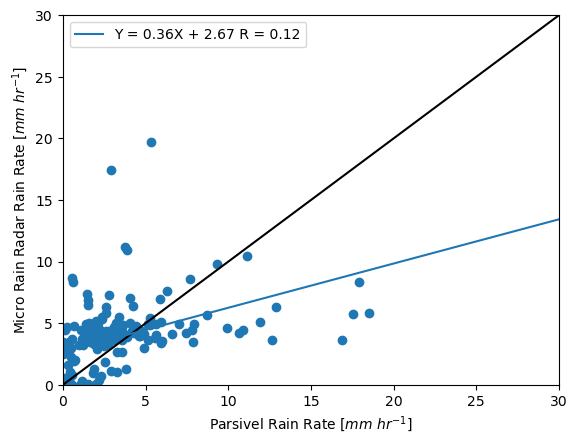

In [74]:
x = parsivel['rain_rate'].values.flatten()
y = ds['RR'].where(ds["Ze"] < 50).isel(Height=0).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.xlabel("Parsivel Rain Rate [$mm\ hr^{-1}$]")
plt.ylabel("Micro Rain Radar Rain Rate [$mm\ hr^{-1}$]")

(0.0, 30.0)

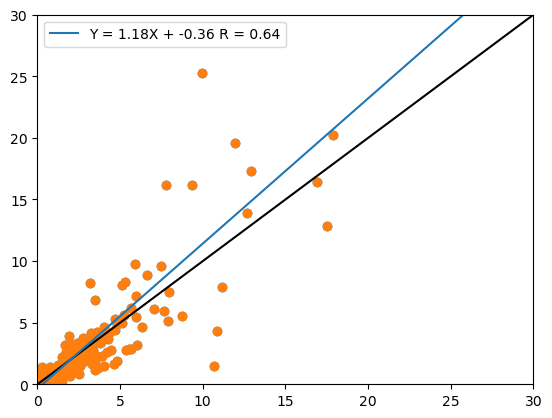

In [15]:
ds_metek = ds_metek.reindex(time=parsivel.time, method='nearest')
x = parsivel['rain_rate'].values.flatten()
y = ds_metek['rainfall_rate'].isel(range=0).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
plt.scatter(parsivel['rain_rate'], ds_metek['rainfall_rate'].isel(range=0).values)
plt.ylim([0, 30])
plt.xlim([0, 30])

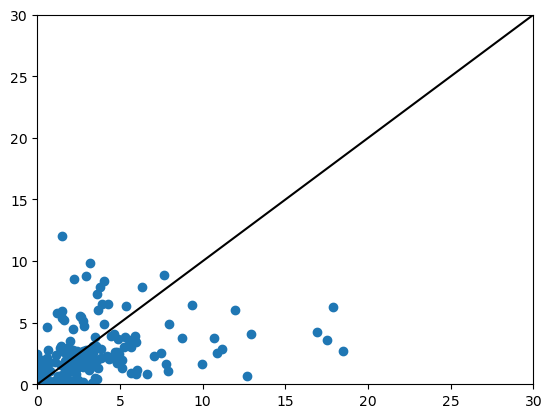

In [61]:
ds_metek = ds_metek.reindex(time=parsivel.time, method='nearest')
x = parsivel['rain_rate'].values.flatten()
y = imptoo_rr.isel(range=2).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

In [36]:
ds_metek[1]

<xarray.Dataset> Size: 413MB
Dimensions:                      (time: 122, range: 31, sample: 64,
                                  index: 268455)
Coordinates:
  * time                         (time) datetime64[ns] 976B 2025-05-20T00:20:...
  * range                        (range) float64 248B 150.0 300.0 ... 4.65e+03
    velocity_bins                (sample) float64 512B ...
Dimensions without coordinates: sample, index
Data variables: (12/17)
    transfer_function            (time, range) float64 30kB ...
    spectral_reflectivity        (index, sample) float64 137MB ...
    drop_size                    (index, sample) float64 137MB ...
    drop_number_density          (index, sample) float64 137MB ...
    percentage_valid_spectra     (time) float64 976B ...
    path_integrated_attenuation  (time, range) float64 30kB ...
    ...                           ...
    altitude                     float64 8B ...
    longitude                    float64 8B ...
    latitude                     float64 8B ...
    spectrum_index               (time, range) float64 30kB ...
    azimuth                      (time) float64 976B ...
    elevation                    (time) float64 976B ...

In [16]:
# N(D) from ds_metek.
# drop_number_density is per velocity bin, units m^-4 (= m^-3 per metre of D).
# spectrum_index maps (time, range) -> index, with -1 marking gates with no valid spectrum.
spec_idx = ds_metek['spectrum_index'].astype(int)
valid = spec_idx >= 0

ND = (ds_metek['drop_number_density'] * 1e-3).isel(index=spec_idx.clip(min=0)).where(valid)
ND.attrs.update(units='m-3 mm-1', long_name='Drop size distribution N(D)')

D = ds_metek['drop_size'].isel(index=spec_idx.clip(min=0)).where(valid)
D.attrs.update(units='mm', long_name='Drop diameter')

ND

<xarray.DataArray 'drop_number_density' (time: 1440, range: 31, sample: 64)> Size: 23MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1440, 31, 64))
Coordinates:
  * time           (time) datetime64[ns] 12kB 2025-05-19T23:56:03 ... 2025-05...
  * range          (range) float64 248B 150.0 300.0 450.0 ... 4.5e+03 4.65e+03
    velocity_bins  (sample) float64 512B ...
Dimensions without coordinates: sample
Attributes:
    units:      m-3 mm-1
    long_name:  Drop size distribution N(D)

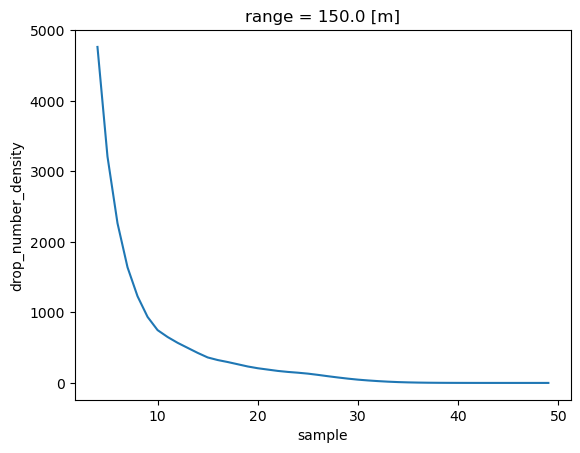

In [18]:
ND.sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim='time').isel(range=0).plot()

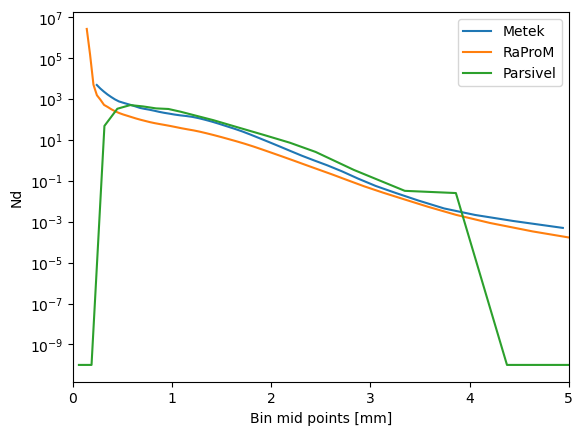

In [21]:
plt.plot(D.sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim='time').isel(range=0), 
         ND.sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim='time').isel(range=0), label="Metek")
(10**(ds["N(D) in function of time and height"].sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim='time').sel(Height=150.))).plot(label="RaProM")
parsivel["Nd"].sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim="time").plot(label="Parsivel")
plt.xlim([0, 5])
plt.yscale('log')
plt.legend()

In [ ]:
parsivel["Nd"].sel(time=slice('2025-05-20T10:00:00', '2025-05-20T10:30:00')).mean(dim="time").values

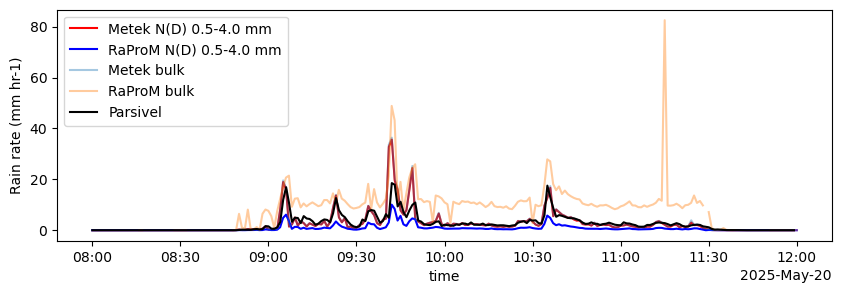

In [52]:
# Rain rate from N(D), restricted to a chosen diameter band [D_min, D_max].
# Lets you compare Metek vs RaProM over the same size window — the two products
# integrate over different native bin ranges, so their bulk RRs are not directly
# comparable.
#
# R = (pi/6) * sum(D^3 * v(D) * N(D) * dD)
#   units: mm^3 * (m/s) * (m^-3 mm^-1) * mm = (m/s) * 1e-9
#   convert m/s -> mm/hr by * 1000 * 3600 = 3.6e6
#   net coefficient: (pi/6) * 3.6e-3
D_min, D_max = 0.5, 4.0  # mm
K = (np.pi / 6.0) * 3.6e-3

def rr_from_nd(N, Dv, v, dim):
    axis = Dv.get_axis_num(dim)
    # dD per bin via central differences along `dim`; NaN-safe by zero-fill then mask back.
    dD = xr.DataArray(np.gradient(np.nan_to_num(Dv.values), axis=axis),
                      dims=Dv.dims, coords=Dv.coords).where(Dv.notnull())
    in_range = (Dv >= D_min) & (Dv <= D_max)
    return (K * Dv**3 * v * N * dD).where(in_range).sum(dim=dim, skipna=True)

# Metek: N(D) and D from the previous cell, v is velocity_bins (m/s) on the 'sample' dim.
RR_metek_band = rr_from_nd(ND, D, ds_metek['velocity_bins'], dim='sample')
RR_metek_band.attrs.update(units='mm hr-1',
                           long_name=f'Rain rate from Metek N(D), {D_min}-{D_max} mm')

# RaProM: 3D N(D) is stored as log10 on (time, Height, DropSize); v(D) from Atlas (1973).
N_raprom = 10 ** ds['N(D) in function of time and height']
D_raprom = ds['DropSize']
v_raprom = 9.65 - 10.3 * np.exp(-0.6 * D_raprom)
RR_raprom_band = rr_from_nd(N_raprom, D_raprom, v_raprom, dim='DropSize')
RR_raprom_band.attrs.update(units='mm hr-1',
                            long_name=f'Rain rate from RaProM N(D), {D_min}-{D_max} mm')

# Compare at the lowest gate against each product's bulk RR.
fig, ax = plt.subplots(figsize=(10, 3))
RR_metek_band.isel(range=0).sel(time=slice(time_range[0], time_range[1])).plot(ax=ax, color='r', label=f'Metek N(D) {D_min}-{D_max} mm')
RR_raprom_band.isel(Height=0).sel(time=slice(time_range[0], time_range[1])).plot(ax=ax, color='b', label=f'RaProM N(D) {D_min}-{D_max} mm')
ds_metek['rainfall_rate'].sel(time=slice(time_range[0], time_range[1])).isel(range=0).plot(ax=ax, alpha=0.4, label='Metek bulk')
out['RR'].sel(time=slice(time_range[0], time_range[1])).isel(Height=0).plot(ax=ax, alpha=0.4, label='RaProM bulk')
parsivel['rain_rate'].sel(time=slice(time_range[0], time_range[1])).plot(label='Parsivel', color='k')
ax.set_ylabel('Rain rate (mm hr-1)')
ax.legend()

0.40333581438055394


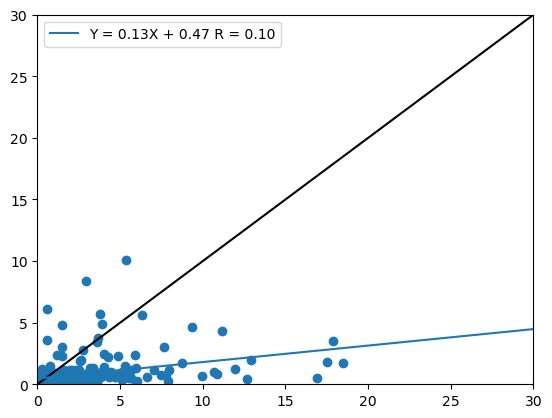

In [44]:
x = parsivel['rain_rate'].values.flatten()
y = RR_raprom_band.isel(Height=0).values.flatten()
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()
print(np.nanmean(y[x>0]/x[x>0]))

In [46]:
out = raprom.process_file('data/0520.raw', calibration=0.403)

File in process  /Users/rjackson/RaProM/data/0520
2026-05-19 20:29:40.666427
2026-05-19 20:30:41.093051




In [47]:
out = xr.open_dataset('data/0520-processed.nc')

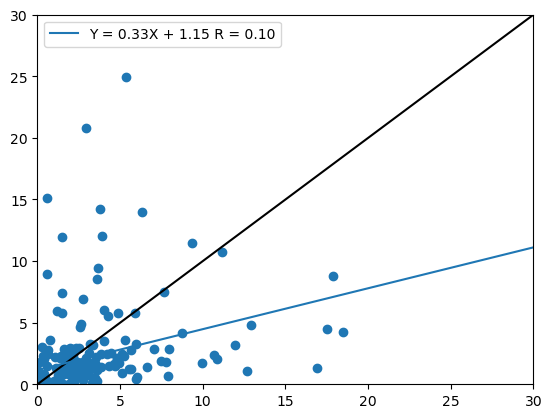

In [51]:
x = parsivel['rain_rate'].values.flatten()
# RaProM: 3D N(D) is stored as log10 on (time, Height, DropSize); v(D) from Atlas (1973).
N_raprom = 10 ** out['N(D) in function of time and height']
D_raprom = out['DropSize']
v_raprom = 9.65 - 10.3 * np.exp(-0.6 * D_raprom)
RR_raprom_band = rr_from_nd(N_raprom, D_raprom, v_raprom, dim='DropSize')
RR_raprom_band.attrs.update(units='mm hr-1',
                            long_name=f'Rain rate from RaProM N(D), {D_min}-{D_max} mm')
y=RR_raprom_band.isel(Height=0)
valid_points = np.logical_and(x > 0, y > 0)
linear_regression_model = LinearRegression()
linear_regression_model.fit(x[valid_points, np.newaxis],
                            y[valid_points])
R = linear_regression_model.score(x[valid_points, np.newaxis], y[valid_points])
plt.scatter(x, y)
plt.ylim([0, 30])
plt.xlim([0, 30])
plt.plot([0, 30], [0, 30], color='k')
xlim = np.array([0, 30])[:, np.newaxis]
m = linear_regression_model.coef_[0]
b = linear_regression_model.intercept_

plt.plot([0, 30], linear_regression_model.predict(xlim), label=f"Y = {m:2.2f}X + {b:2.2f} R = {R:0.2f}")
plt.legend()